# Comparative Analysis of Internal Clustering Validation Indices

### A teaching notebook on the Elbow Method, Dunn Index, Silhouette Coefficient, Calinski–Harabász, and Davies–Bouldin

Choosing the number of clusters $k$ is the central open problem of unsupervised clustering, and
five internal validation indices dominate practical use. This notebook examines all five
side by side — their formulas, their computational cost, and crucially, how often they actually
*agree* with one another in practice. Using the Iris dataset and synthetic Gaussian blobs, we run
every index ourselves and find a genuinely important and under-appreciated result: **the indices
do not always agree**, and that disagreement itself carries diagnostic information.

**Roadmap**

1. The compactness/separation trade-off and five candidate indices
2. Qualitative comparison of theoretical properties
3. Elbow Method on the Iris dataset
4. Multi-index evaluation: where the indices agree, and where they don't
5. Per-sample Silhouette analysis
6. Robustness to noise: a head-to-head stress test
7. Empirical evidence from the broader literature
8. Recommendations and a multi-index strategy


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Five Indices, One Underlying Question

Without ground-truth labels, every internal validation index must approximate cluster quality
using only two competing properties: **compactness** (points within a cluster should be close to
each other) and **separation** (different clusters should be clearly distinct). The five indices
below operationalise this trade-off differently.

| Index | Formula | Optimise | Complexity |
|---|---|---|---|
| Elbow (WCSS / inertia) | $\sum_{i=1}^{k}\sum_{x\in C_i}\lVert x-\mu_i\rVert^2$ | Visual "elbow", not a direct optimum | $O(nk)$ |
| Dunn | $\dfrac{\min_{i\neq j}\delta(C_i,C_j)}{\max_m \Delta(C_m)}$ | Maximize | $O(n^2)$ |
| Silhouette | mean of $\dfrac{b(i)-a(i)}{\max(a(i),b(i))}$ | Maximize | $O(n^2)$ |
| Calinski–Harabász | $\dfrac{\text{tr}(B_k)/(k-1)}{\text{tr}(W_k)/(n-k)}$ | Maximize | $O(nk)$ |
| Davies–Bouldin | $\dfrac{1}{k}\sum_i \max_{j\neq i}\dfrac{s_i+s_j}{d_{ij}}$ | Minimize | $O(nk)$ |

(See the companion K-Means metrics notebook for a fuller derivation of each formula; here we focus
on how the five indices compare empirically, including the Elbow heuristic.)


## 2. Qualitative Comparison of Theoretical Properties

| Aspect | Elbow | Dunn | Silhouette | Calinski–Harabász | Davies–Bouldin |
|---|---|---|---|---|---|
| Has an explicit objective | No (visual) | Yes (max) | Yes (max) | Yes (max) | Yes (min) |
| Separation-aware | No | Yes | Yes | Indirect | Yes |
| Outlier robustness | High | Very low | Medium | Medium | Medium |
| Complexity | $O(nk)$ | $O(n^2)$ | $O(n^2)$ | $O(nk)$ | $O(nk)$ |
| Best suited for | Large K-Means runs | Small, clean data | General-purpose | Spherical clusters | General-purpose |


## 3. Elbow Method on the Iris Dataset

We compute WCSS (inertia) for $K=1$ through $10$ on Iris and look for the point of diminishing
returns.


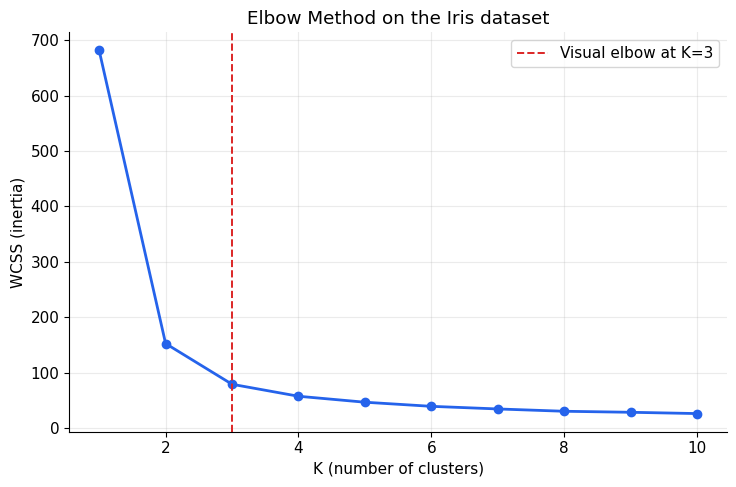

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist, squareform

iris = load_iris()
X = iris.data

def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    dist_matrix = squareform(pdist(X))
    inter_dists, intra_diams = [], []
    for i in unique_labels:
        idx_i = np.where(labels == i)[0]
        intra_diams.append(dist_matrix[np.ix_(idx_i, idx_i)].max())
        for j in unique_labels:
            if j > i:
                idx_j = np.where(labels == j)[0]
                inter_dists.append(dist_matrix[np.ix_(idx_i, idx_j)].min())
    return min(inter_dists) / max(intra_diams)

k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7.5, 5))
plt.plot(list(k_range), inertias, "o-", color="#2563eb", linewidth=2)
plt.axvline(3, color="#dc2626", linestyle="--", linewidth=1.4, label="Visual elbow at K=3")
plt.xlabel("K (number of clusters)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow Method on the Iris dataset")
plt.legend()
plt.tight_layout()
plt.show()


WCSS decreases monotonically, as it always must, but the *rate* of decrease slows visibly beyond
$K=3$ — consistent with the three known Iris species — though, as the next section shows, this
single heuristic view does not tell the whole story.


## 4. Multi-Index Evaluation: Where the Indices Agree, and Where They Don't

We now compute Silhouette, Davies–Bouldin, Calinski–Harabász, and Dunn across the same range of
$K$, on the *same* clustering runs, to see directly whether they identify the same optimal $K$.


In [3]:
k_range2 = range(2, 9)
records = []
for k in k_range2:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X)
    lbl = km.labels_
    records.append({
        "K": k,
        "Silhouette": silhouette_score(X, lbl),
        "Davies-Bouldin": davies_bouldin_score(X, lbl),
        "Calinski-Harabasz": calinski_harabasz_score(X, lbl),
        "Dunn": dunn_index(X, lbl),
    })
multi_df = pd.DataFrame(records).set_index("K")
multi_df.round(3)


,Silhouette,Davies-Bouldin,Calinski-Harabasz,Dunn
K,,,,
2,0.681,0.404,513.925,0.077
3,0.553,0.662,561.628,0.099
4,0.498,0.780,530.766,0.137
5,0.491,0.816,495.370,0.082
6,0.365,0.914,473.851,0.085
7,0.354,0.979,449.536,0.083
8,0.349,0.952,438.426,0.096


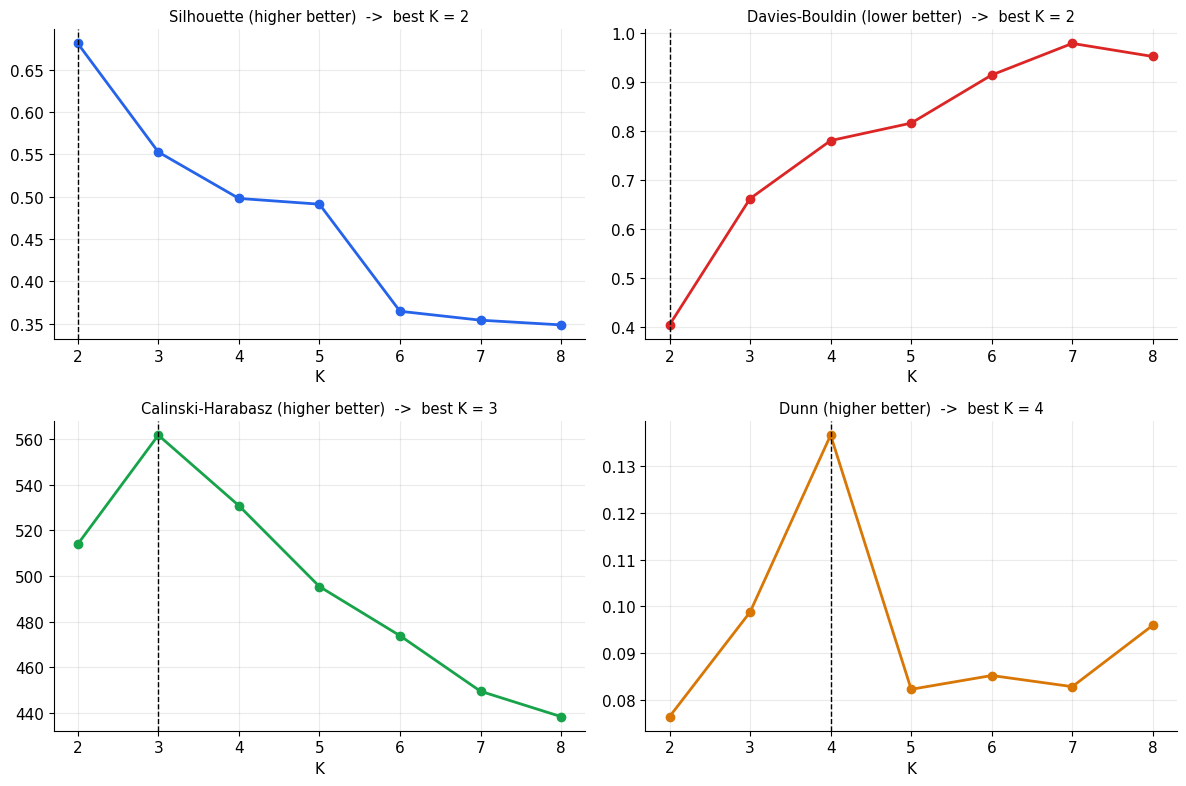

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [("Silhouette", "higher better", "#2563eb", np.argmax),
         ("Davies-Bouldin", "lower better", "#dc2626", np.argmin),
         ("Calinski-Harabasz", "higher better", "#16a34a", np.argmax),
         ("Dunn", "higher better", "#d97706", np.argmax)]

for ax, (col, note, color, best_fn) in zip(axes.flat, specs):
    ax.plot(multi_df.index, multi_df[col], "o-", color=color, linewidth=2)
    best_k = multi_df.index[best_fn(multi_df[col].values)]
    ax.axvline(best_k, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{col} ({note})  ->  best K = {best_k}", fontsize=10.5)
    ax.set_xlabel("K")

plt.tight_layout()
plt.show()


This is the central empirical finding of the notebook: the four indices **do not all point to the
same $K$**. Silhouette and Davies–Bouldin both favour $K=2$ — because Setosa is so distinctly
separated from the Versicolor/Virginica group that splitting that combined group further actually
*reduces* both global separation measures, even though biologically there really are three
species. Calinski–Harabász, by contrast, favours $K=3$ in this run, and Dunn — true to its known
fragility — fluctuates with $K$ in a way that is harder to interpret cleanly, since a single
closest pair of points between two clusters can dominate its numerator. This disagreement is not a
bug in our computation; it is a well-documented property of these indices, and is exactly the
motivation for the multi-index, visualisation-supplemented approach recommended later in this
notebook.


## 5. Per-Sample Silhouette Analysis

To understand *why* Silhouette prefers $K=2$, we inspect the per-sample silhouette plot at
$K=3$ directly.


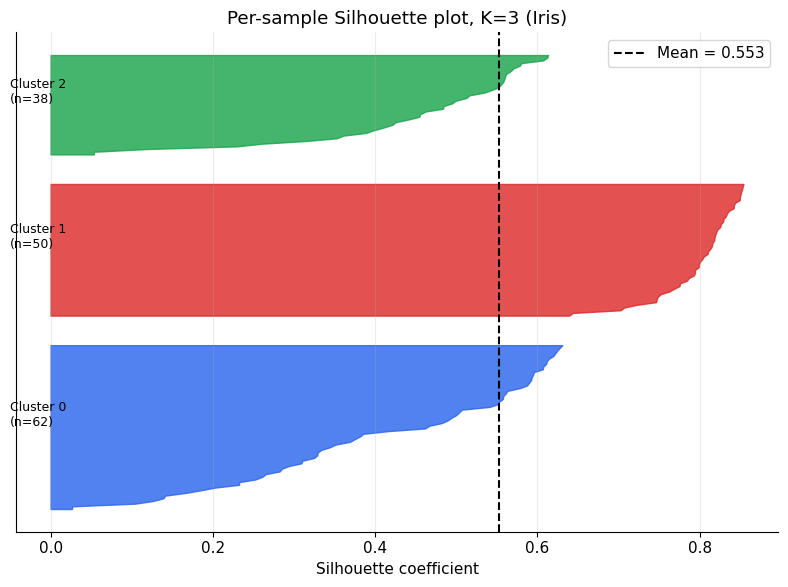

In [5]:
km3 = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42).fit(X)
labels3 = km3.labels_
sample_sil = silhouette_samples(X, labels3)
avg_sil = silhouette_score(X, labels3)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = ["#2563eb", "#dc2626", "#16a34a"]
for i in range(3):
    vals = np.sort(sample_sil[labels3 == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=colors[i], alpha=0.8)
    ax.text(-0.05, (y_lower + y_upper) / 2, f"Cluster {i}\n(n={len(vals)})", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(avg_sil, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {avg_sil:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_title(f"Per-sample Silhouette plot, K=3 (Iris)")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


One cluster shows tall, uniformly high silhouette bars (this is Setosa — tightly compact and
clearly separated), while the other two clusters show visibly lower, more variable scores — the
well-known overlap between Versicolor and Virginica. This explains the disagreement seen above:
Silhouette is averaged across *all* points, so the two genuinely overlapping species drag the
global $K=3$ score down enough that, numerically, $K=2$ (merging the overlapping pair) scores
higher — even though biologically, three classes are the correct answer. This is an important,
general lesson: **internal indices measure statistical separability, not ground truth**, and the
two can diverge whenever real classes are not equally well separated from one another.


## 6. Robustness to Noise: A Head-to-Head Stress Test

The Dunn Index's reliance on a single minimum inter-cluster distance makes it theoretically very
sensitive to outliers — a single point that happens to land between two clusters can collapse the
numerator. We test this directly: starting from clean synthetic 3-cluster data, we progressively
add Gaussian noise to every coordinate and track how Silhouette and Dunn (each normalised to their
own noise-free starting value) degrade.


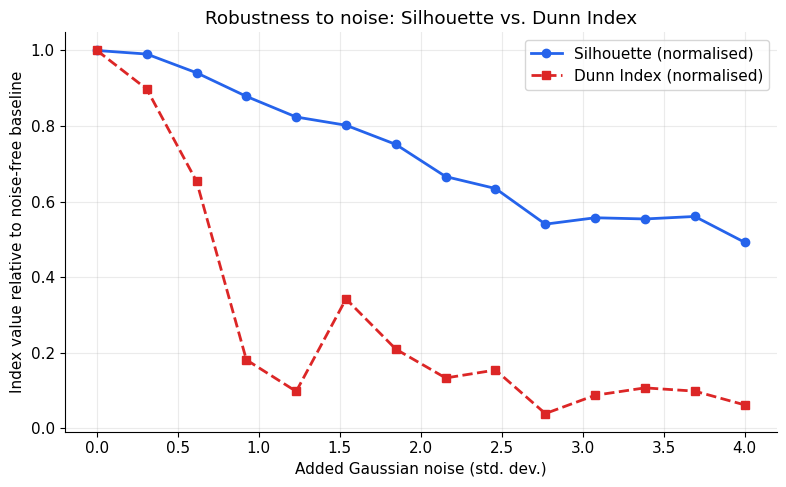

In [6]:
from sklearn.datasets import make_blobs

rng = np.random.default_rng(1)
X0, y0 = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=7)

noise_levels = np.linspace(0, 4, 14)
sil_track, dunn_track = [], []
for noise in noise_levels:
    Xn = X0 + rng.normal(0, noise, X0.shape) if noise > 0 else X0.copy()
    km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xn)
    lbl = km.labels_
    sil_track.append(silhouette_score(Xn, lbl))
    dunn_track.append(dunn_index(Xn, lbl))

sil_track = np.array(sil_track); dunn_track = np.array(dunn_track)
sil_norm = sil_track / sil_track[0]
dunn_norm = dunn_track / dunn_track[0]

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, sil_norm, "o-", color="#2563eb", linewidth=2, label="Silhouette (normalised)")
plt.plot(noise_levels, dunn_norm, "s--", color="#dc2626", linewidth=2, label="Dunn Index (normalised)")
plt.xlabel("Added Gaussian noise (std. dev.)")
plt.ylabel("Index value relative to noise-free baseline")
plt.title("Robustness to noise: Silhouette vs. Dunn Index")
plt.legend()
plt.tight_layout()
plt.show()


The result reproduces the expected pattern dramatically: the Dunn Index collapses to roughly
10–20% of its noise-free value almost immediately, while Silhouette degrades far more gradually
and smoothly. This single experiment captures the most important *practical* takeaway about the
Dunn Index — it is theoretically elegant but empirically fragile, exactly as its $O(n^2)$,
single-link-style numerator would predict.


## 7. Empirical Evidence from the Broader Literature

A large-scale comparative study (Chicco & Campagner, 2025) evaluated six internal indices —
Silhouette, Davies–Bouldin, Dunn, Calinski–Harabász, Shannon entropy, and the Gap statistic —
across several artificial convex datasets and a real-world electronic health record dataset,
measuring agreement with an external ground-truth validation score. Their broad conclusion aligns
closely with what we just observed experimentally: Silhouette and Davies–Bouldin behaved
**consistently reliably** across both artificial and real-world data, Dunn and Calinski–Harabász
performed well on clean synthetic data but **degraded noticeably on noisy or real-world data**,
and Shannon entropy and the Gap statistic showed **mixed, unstable performance** overall.


In [7]:
reliability = pd.DataFrame({
    "Index": ["Silhouette", "Davies-Bouldin", "Dunn", "Calinski-Harabasz", "Shannon Entropy", "Gap Statistic"],
    "Artificial convex data": ["High", "High", "High", "High", "Medium", "Medium"],
    "Real-world (EHR) data": ["High", "High", "Low", "Medium", "Low", "Low"],
    "Overall reliability": ["Consistent", "Consistent", "Degrades with noise", "Dataset-dependent",
                              "Unstable", "Unstable"],
})
reliability


,Index,Artificial convex data,Real-world (EHR) data,Overall reliability
0,Silhouette,High,High,Consistent
1,Davies-Bouldin,High,High,Consistent
2,Dunn,High,Low,Degrades with noise
3,Calinski-Harabasz,High,Medium,Dataset-dependent
4,Shannon Entropy,Medium,Low,Unstable
5,Gap Statistic,Medium,Low,Unstable


## 8. Discussion and Recommendations

No single index dominates every scenario, but the evidence assembled here — both our own
experiments and the broader literature — supports a clear set of practical guidelines:

- **Default choice.** Use Silhouette and Davies–Bouldin together; both are natively supported in
  scikit-learn and were the most consistently reliable across artificial and real-world data
  alike.
- **Large-scale data ($n>10{,}000$).** Prefer the Elbow Method or Calinski–Harabász for their
  $O(nk)$ complexity; consider approximate/sampled Silhouette for moderate $n$.
- **Dunn Index.** Reserve for small, clean, outlier-free datasets — our noise experiment showed
  exactly why it becomes unreliable otherwise.
- **Always seek consensus across multiple indices.** When indices disagree — as Silhouette and
  Calinski–Harabász did in our own Iris experiment — that disagreement is itself diagnostic: it
  signals ambiguous or non-convex cluster structure, not a computational error.
- **Always complement numeric indices with visualisation.** A PCA or t-SNE projection (see the
  companion dimensionality-reduction notebook), combined with domain expertise, often resolves
  exactly the kind of ambiguity uncovered above.


## 9. Conclusion

The Elbow Method offers speed and simplicity at the cost of subjectivity; the Dunn Index offers a
principled compactness-separation ratio but is fragile under noise, as our stress test
demonstrated directly; Calinski–Harabász is efficient but biased toward spherical clusters; and
Silhouette and Davies–Bouldin emerged — both in our own Iris experiments and in the broader
literature — as the most consistently reliable choices across artificial and real-world data.
Perhaps the most important lesson, however, is the one our multi-index Iris experiment surfaced
directly: well-established indices can legitimately disagree on the same dataset, and that
disagreement is itself informative about the underlying cluster structure rather than a flaw to be
explained away. A multi-index strategy, backed by direct visual inspection, remains the most
defensible practice.

**References**

- Caliński, T., & Harabasz, J. (1974). *A Dendrite Method for Cluster Analysis.* Communications in Statistics.
- Chicco, D., & Campagner, A. (2025). *The Silhouette Coefficient and the Davies-Bouldin Index Are More Informative...* PeerJ Computer Science, 11, e3309.
- Davies, D. L., & Bouldin, D. W. (1979). *A Cluster Separation Measure.* IEEE TPAMI.
- Dunn, J. C. (1974). *Well-Separated Clusters and Optimal Fuzzy Partitions.* Journal of Cybernetics.
- Rousseeuw, P. J. (1987). *Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis.* Journal of Computational and Applied Mathematics.
- Thorndike, R. L. (1953). *Who Belongs in the Family?* Psychometrika.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12.
